# GIN and FiLM curvature training across depths

**Role:** Training.

Train ordinary GIN models, size-conditioned FiLM models, or both across depths, widths, seeds and organoid folds. Every model receives the complete observed fate panel, with optional marker exclusivity. A shared timepoint filter selects the cohort before splitting; optional train-only baseline residualization removes organoid-level curvature. The notebook displays validation results and saves models, exact prepared datasets, splits and fitted transformations under `training_results/gin_depth_training/`. Permutation/ring controls belong in graph-control training, marker combinations in lineage-removal training, and missing-fate training in the masking notebook.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Configuration

Choose the shared experiment/timepoint filters, full or exclusive fate encoding, GNN depths and `model_types` (`gin`, `film`, or both). FiLM requires `log_num_cells` in `global_features`; it also passes the configured globals to the head. Depth zero is a control without message passing or FiLM layers. `n_folds=1` creates a single holdout. Set an optional `tag` to identify the run; output names include its creation timestamp.

In [2]:
import copy, json, pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import attach_metadata_to_graphs, load_aux_metadata_for_dir, load_marker_names_from_dir
from src.data.filters import (filter_graphs_by_blacklist, load_graph_blacklist_from_dir,
    filter_graphs_by_timepoints, filter_graphs_by_metadata, filter_graphs_by_sphericity, filter_graphs_by_numeric_metadata)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.training.preparation import prepare_fold
from src.models.gnn import GINCurvature, SizeFiLMGINCurvature
from src.models.size_models import seed_all
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term
from src.inference.predict import predict_targets
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.provenance import workflow_fingerprint
from src.artifacts.paths import training_run_path
from src.analysis.metrics.evaluation import compare_baseline_mse
from src.training.progress import TrainingProgress


In [3]:
# Execution switches
RUN_TRAINING = True  # Enable fitting and saving new model checkpoints.

SETTINGS = dict(
    # Run identity
    tag='single20250929_exclusive_restored',  # Optional purpose label; letters, digits, underscores and hyphens.

    # Dataset and targets
    dataset='after_cleanup_restored_exclusive',  # Source dataset folder under training_data/.
    target_indices=[0],  # Target columns to predict; [0] selects Gaussian curvature.

    # Data filters
    measurement_datasets=['20250929'],  # Shared experiment selection for train/validation; None includes every experiment.
    timepoints=['day4', 'day4p5', 'day4p5-more'],  # Shared cohort timepoints for train/validation; None keeps all, or use a list of labels.
    blacklist=True,  # Exclude organoids listed in the dataset blacklist.
    sphericity_max=0.93,  # Maximum retained sphericity; None disables this filter where supported.
    complexity_min=None,  # Minimum retained complexity; None disables this filter.
    interpolate_outliers=True,  # Replace extreme targets using neighboring cells.
    outlier_quantiles=[.005, .995],  # Lower and upper quantiles defining target outliers.

    # Fate encoding
    exclusive_markers=True,  # Apply ordered rules so each cell has at most one fate.

    # Model grid
    model_types=['gin'],  # Choose gin, film, or both; every model uses the complete fate panel.
    depths=[0, 1, 2, 3, 4],  # GNN message-passing depths or control-model ring radii.
    hidden_dims=[128],  # Hidden widths to compare in the model grid.
    seeds=[42],  # Model initialization and training seeds to compare.

    # Data splits
    n_folds=5,  # n_folds=1: single holdout; larger values: organoid folds.
    val_fraction=.2,  # Fraction of organoids held out when n_folds=1.
    split_seed=42,  # Random seed for organoid train/validation membership.

    # Target residualization
    residualize=False,  # Subtract the always-trained baseline from targets; False keeps original targets.
    baseline_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Global features used only by the baseline model.

    # Model parameters
    film_hidden_dim=16,  # Width of the log-count FiLM conditioning network.
    global_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Global columns appended to the prediction head.
    dropout=.1,  # Probability of hidden-feature dropout during training.
    norm='batch',  # Hidden normalization: batch, layer, or none.
    residual=True,  # Enable residual connections within the GNN.

    # Training hyperparameters
    lr=3e-4,  # Optimizer learning rate.
    weight_decay=1e-4,  # AdamW weight-decay coefficient.
    batch_size=128,  # Number of graphs or subgraphs per batch.
    max_epochs=500,  # Maximum optimization epochs per fitted model.
    patience=30,  # Early-stopping patience, in epochs.
    num_workers=0,  # DataLoader worker processes; 0 loads in the main process.
    loss_name='gaussian',  # Prediction loss; gaussian fits a mean and uncertainty.

    # Training loss
    edge_loss_weight=.2,  # Weight of the auxiliary edge-consistency penalty.
    edge_loss_params=dict(
        weighted=False,  # Weight edge penalties by the target difference.
        alpha=2.,  # Exponent controlling edge-loss weights.
        normalize_by='graph_std',  # Scale used to normalize the edge penalty.
        clip_weight=4.,  # Maximum weight assigned to one edge penalty.
    ),  # Options for computing the auxiliary edge penalty.

    # Baseline training
    baseline_hidden_dim=64,  # Hidden width of the global-only baseline.
    baseline_max_epochs=2000,  # Maximum training epochs for the global baseline.
    baseline_patience=30,  # Baseline early-stopping patience, in epochs.

)  # Explicit run configuration, saved alongside the models.

# Training hyperparameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use CUDA when available, otherwise CPU.

# Paths and outputs
RESUME_RUN = None  # Existing run folder to resume; None starts a new timestamped run.
RUN_DIR = ROOT / 'training_results/gin_depth_training' / RESUME_RUN if RESUME_RUN else training_run_path(ROOT, 'gin_depth_training', SETTINGS['tag'])  # Saved or new run directory.

# Regional evaluation (annotations only; never model inputs)
REGION_SETTINGS = dict(
    crypt_max=.8,  # Crypt body: nearest normalized distance s < this boundary.
    neck_max=1.2,  # Qualified neck: crypt_max <= s <= neck_max; beyond is the villus proxy.
    neck_config=dict(
        minimum_crypt_cells=10,  # Assigned cells within s <= 1 required per crypt.
        minimum_relative_depth=.05,  # Minimum circumference trough depth relative to C(1).
        plateau_max_range=.10,  # Maximum relative circumference variation for a flat section.
        plateau_max_slope=.25,  # Maximum absolute relative slope of a flat section.
        plateau_exit_rise=.10,  # Required circumference rise after a flat section.
    ),
)

# Progress display
SHOW_PROGRESS = True  # Show one persistent panel for models, epochs and completed tasks.
PRINT_EPOCHS = False  # Also print each epoch; False keeps the training output compact.


## Load and filter the cohort

Attach metadata and retain requested organoids. Optional outlier interpolation follows the existing cohort-level preprocessing; its fitted information is saved. Marker exclusivity changes only fate channels and preserves unassigned cells and graph topology.
Each active organoid filter prints kept/total counts and the retained fraction for each dataset and timepoint. Counts refer to the cohort entering that step, after any preceding filters.

The optional `measurement_datasets` filter selects original experiments for both training and validation before any target-cleanup statistics are estimated. Dataset folder selection and experiment selection are separate settings.

In [4]:
data_dir = ROOT/'training_data'/SETTINGS['dataset']  # Dataset directory supplying graphs and metadata.
graphs = load_graph_dataset_from_dir(str(data_dir))
attach_metadata_to_graphs(graphs, load_aux_metadata_for_dir(str(data_dir)), exclude_keys=None)
if SETTINGS['measurement_datasets'] is not None:
    graphs = filter_graphs_by_metadata(graphs, key='dataset', keep_values=set(SETTINGS['measurement_datasets']),
                                      missing='drop', inplace=False, print_summary=True)
graphs = filter_graphs_by_timepoints(graphs, SETTINGS['timepoints'], print_summary=True)
graphs = select_graph_targets(graphs, target_indices=SETTINGS['target_indices'], inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if not marker_names or SETTINGS['target_indices'] != [0]:
    raise ValueError('This workflow requires named fate channels and scalar Gaussian curvature.')
if SETTINGS['blacklist']:
    graphs = filter_graphs_by_blacklist(graphs, load_graph_blacklist_from_dir(data_dir), print_summary=True)
if SETTINGS['sphericity_max'] is not None:
    graphs = filter_graphs_by_sphericity(graphs, max_sphericity=SETTINGS['sphericity_max'], print_summary=True)
if SETTINGS['complexity_min'] is not None:
    graphs = filter_graphs_by_numeric_metadata(graphs, key='complexity', min_value=SETTINGS['complexity_min'], allow_missing=False, print_summary=True)
if SETTINGS['exclusive_markers']:
    for g in graphs:
        g.x = torch.as_tensor(exclusive_markers(g.x.cpu().numpy(), marker_names), dtype=g.x.dtype)
if SETTINGS['interpolate_outliers']:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(graphs, clip_quantiles=SETTINGS['outlier_quantiles'])
else:
    outlier_info = None
assert len(graphs) >= 2 and len({g.organoid_str for g in graphs}) == len(graphs)
cohort = pd.DataFrame([dict(organoid_str=g.organoid_str, n_cells=len(g.x),
                          timepoint=str(g.meta.get('timepoint', 'unknown'))) for g in graphs])
display(cohort.groupby('timepoint').agg(organoids=('organoid_str','size'), median_N=('n_cells','median')))


Loaded 1500 graphs; skipped 0.


filter_graphs_by_metadata(key='dataset'): kept 1222 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              290    290    1.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5                0    278    0.000
filter_graphs_by_metadata(key='timepoint'): kept 932 / 1222 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
filter_graphs_by_blacklist(n_keys=17): kept 917 / 932 graphs

dataset          timepoint          kept  total     frac
-

filter_graphs_by_sphericity(max_sphericity=0.93): kept 675 / 917 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                233    330    0.706
20250929         day4p5               94    112    0.839
20250929         day4p5-more         348    475    0.733


=== Target outlier interpolation report ===
Quantiles: [0.005, 0.995]
target 0: range=[-0.199383, 0.238507] | outliers=3162 | replaced=3162 | fallback=36 | rejected_interp=36


,organoids,median_N
timepoint,,
day4,233,318.0
day4p5,94,406.5
day4p5-more,348,529.0


## Organism-level splits

Partition the cohort already selected by the shared `timepoints` setting. Training and validation draw from the same allowed timepoints; no organoid can enter both partitions. Display fold membership counts by timepoint before fitting.

In [5]:
rng = np.random.default_rng(SETTINGS['split_seed'])
order = rng.permutation(len(graphs))
fold_count = SETTINGS['n_folds']
if not 1 <= fold_count <= len(graphs):
    raise ValueError('Invalid number of folds')
if fold_count == 1:
    if not 0 < SETTINGS['val_fraction'] < 1:
        raise ValueError('Invalid validation fraction')
    val_sets = [order[:max(1, min(len(order)-1, round(len(order)*SETTINGS['val_fraction'])))]]
else:
    val_sets = np.array_split(order, fold_count)
splits = []
for fold, val in enumerate(val_sets):
    split = dict(fold=fold, train_indices=np.setdiff1d(order, val).tolist(),
                 val_indices=val.tolist())
    if not split['train_indices'] or not split['val_indices']:
        raise ValueError(f'Empty cohort split: fold {fold}')
    splits.append(split)
membership = [dict(fold=s['fold'], **graph_membership(
    train=[graphs[i] for i in s['train_indices']], validation=[graphs[i] for i in s['val_indices']])) for s in splits]
display(pd.DataFrame([dict(fold=s['fold'], role=role, timepoint=cohort.iloc[i].timepoint)
    for s in splits for role in ('train', 'val') for i in s[role + '_indices']])
    .groupby(['fold', 'role', 'timepoint']).size().rename('organoids').to_frame())

organoids
fold role  timepoint             
0    train day4               180
           day4p5              74
           day4p5-more        286
     val   day4                53
           day4p5              20
           day4p5-more         62
1    train day4               181
           day4p5              72
           day4p5-more        287
     val   day4                52
           day4p5              22
           day4p5-more         61
2    train day4               191
           day4p5              80
           day4p5-more        269
     val   day4                42
           day4p5              14
           day4p5-more         79
3    train day4               188
           day4p5              75
           day4p5-more        277
     val   day4                45
           day4p5              19
           day4p5-more         71
4    train day4               192
           day4p5              75
           day4p5-more        273
     val   day4                41
           day4p5              19
           day4p5-more         75

## Fit, evaluate and save

Prepare each fold once, fitting global standardization, the baseline (always trained) and the target transform on training organoids. Train all requested depths and GIN/FiLM variants on those exact inputs. Matching layers use the same initial weights for a given seed. Save each completed checkpoint immediately, together with its history and references to the shared fold inputs. The main notebook has no subset, permutation or masking training path.
The persistent progress panel reports the active model/depth/fold/seed (and signal, marker subset or masking rate), trained models remaining, epoch, best stopping metric, patience used and elapsed time. Baselines and copied/reused checkpoints have separate counters. The completion table updates in place and is also written to `training_progress.csv` in the run folder. Standard models stop on validation MAE; masking models stop on intact inner-validation MSE in transformed units. Epoch bars show the maximum budget, not an estimated completion time. `PRINT_EPOCHS=True` restores detailed epoch output. Interrupted or failed tasks are labelled and are not counted as completed.


`RESUME_RUN` reuses completed checkpoints and saved fold preparation after checking settings, exact membership and data. Only missing models are fitted; a model interrupted before checkpoint saving restarts from its configured seed. Set `RESUME_RUN=None` for a fresh run.

In [6]:
if not RUN_TRAINING:
    raise RuntimeError('Review settings, then set RUN_TRAINING=True to fit and save a new run.')
if not SETTINGS['model_types'] or len(set(SETTINGS['model_types'])) != len(SETTINGS['model_types']) or not set(SETTINGS['model_types']) <= {'gin', 'film'}:
    raise ValueError('model_types must contain gin, film, or both exactly once')
if 'film' in SETTINGS['model_types'] and 'log_num_cells' not in SETTINGS['global_features']:
    raise ValueError('FiLM requires log_num_cells in global_features')
provenance = workflow_fingerprint(ROOT/'experiments/training/gin_depth_training.ipynb')
records, scores, histories = [], [], {}
baseline_rows = []
if RESUME_RUN:
    assert json.loads((RUN_DIR/'settings.json').read_text()) == SETTINGS, 'Resume settings differ.'
    assert json.loads((RUN_DIR/'splits.json').read_text()) == membership, 'Resume splits differ.'
    assert json.loads((RUN_DIR/'exclusivity_rules.json').read_text()) == EXCLUSIVITY_RULES, 'Exclusivity rules changed.'
    saved_cohort = load_bundle(RUN_DIR/'cohort')
    assert saved_cohort['all_marker_names'] == marker_names
    assert set(saved_cohort['raw_graphs']) == {g.organoid_str for g in graphs}
    for graph in graphs:
        original = saved_cohort['raw_graphs'][graph.organoid_str]
        for attr in ('x', 'y', 'edge_index'):
            assert torch.equal(getattr(graph, attr), getattr(original, attr)), f'Resume data changed: {attr}'
        assert pickle.dumps(graph.meta) == pickle.dumps(original.meta), 'Resume metadata changed.'
    del saved_cohort
    if (RUN_DIR/'models.json').exists():
        records = json.loads((RUN_DIR/'models.json').read_text())
        scores = pd.read_csv(RUN_DIR/'validation_mse.csv').drop(columns=['baseline_mse', 'mse_minus_baseline']).to_dict('records')
        for record in records:
            histories[record['key']] = load_bundle(RUN_DIR/record['bundle'])['history']
    if (RUN_DIR/'baseline_validation_mse.csv').exists():
        baseline_rows = pd.read_csv(RUN_DIR/'baseline_validation_mse.csv').to_dict('records')
    (RUN_DIR/f'resume_provenance_{datetime.now():%Y%m%d_%H%M%S}.json').write_text(json.dumps(
        dict(code_sha256=provenance, device=DEVICE, reused_models=len(records)), indent=2))
else:
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    (RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS, indent=2))
    (RUN_DIR/'splits.json').write_text(json.dumps(membership, indent=2))
    (RUN_DIR/'exclusivity_rules.json').write_text(json.dumps(EXCLUSIVITY_RULES, indent=2))
    cohort.to_csv(RUN_DIR/'cohort.csv', index=False)
    (RUN_DIR/'provenance.json').write_text(json.dumps({'code_sha256':provenance,'device':DEVICE}, indent=2))
    save_bundle(RUN_DIR/'cohort', dict(raw_graphs={g.organoid_str:g for g in graphs},
        all_marker_names=marker_names, settings=SETTINGS, outlier_info=outlier_info),
        splits=membership, provenance={'code_sha256':provenance})
completed_keys = {record['key'] for record in records}
total_models = len(splits) * len(SETTINGS['depths']) * len(SETTINGS['hidden_dims']) * len(SETTINGS['seeds']) * len(SETTINGS['model_types'])
pending_baselines = sum(not (RUN_DIR/f"inputs/fold_{s['fold']}_all_intact").exists() for s in splits)
progress_path = RUN_DIR / (f'training_progress_resume_{datetime.now():%Y%m%d_%H%M%S}.csv' if RESUME_RUN else 'training_progress.csv')
print(f'Reusing {len(records)} completed models; training {total_models-len(records)} remaining models.')
with TrainingProgress(total_models-len(records), total_baselines=pending_baselines,
                      show=SHOW_PROGRESS, print_epochs=PRINT_EPOCHS, log_path=progress_path) as progress:
    for split in splits:
        input_bundle = f"inputs/fold_{split['fold']}_all_intact"
        if (RUN_DIR/input_bundle).exists():
            prepared = load_bundle(RUN_DIR/input_bundle)
        else:
            seed_all(SETTINGS['split_seed'] + split['fold'])
            with progress.task(kind='baseline', model='Global baseline', fold=split['fold']):
                prepared = prepare_fold(graphs, split, global_features=SETTINGS['global_features'],
                    residualize=SETTINGS['residualize'], baseline_features=SETTINGS['baseline_features'],
                    baseline_kwargs=dict(hidden_dim=SETTINGS['baseline_hidden_dim'], max_epochs=SETTINGS['baseline_max_epochs'],
                        patience=SETTINGS['baseline_patience'], batch_size=SETTINGS['batch_size'], num_workers=SETTINGS['num_workers'],
                        train_kwargs=dict(device=DEVICE)))
            save_bundle(RUN_DIR/input_bundle, dict(**prepared, marker_names=marker_names),
                        splits=membership[split['fold']], provenance={'code_sha256':provenance})
        baseline_rows = [row for row in baseline_rows if row['fold'] != split['fold']]
        baseline_rows.extend(dict(fold=split['fold'], **row) for row in prepared['baseline_validation_mse'])
        pd.DataFrame(baseline_rows).to_csv(RUN_DIR/'baseline_validation_mse.csv', index=False)
        groups = prepared['groups']
        for depth in SETTINGS['depths']:
            for width in SETTINGS['hidden_dims']:
                for seed in SETTINGS['seeds']:
                    kw = dict(n_markers=len(marker_names), hidden_dim=width, num_layers=depth,
                              dropout=SETTINGS['dropout'], residual=SETTINGS['residual'],
                              norm=SETTINGS['norm'], global_dim=len(SETTINGS['global_features']))
                    seed_all(seed)
                    common_model = GINCurvature(**kw)
                    for family in SETTINGS['model_types']:
                        key = f"{family}_all_intact_d{depth}_h{width}_f{split['fold']}_s{seed}"
                        if key in completed_keys:
                            continue
                        with progress.task(model=family, subset='all', signal='intact', depth=depth, width=width, fold=split['fold'], seed=seed):
                            if family == 'gin':
                                model = copy.deepcopy(common_model)
                            else:
                                seed_all(seed)
                                model = SizeFiLMGINCurvature(**kw, film_hidden_dim=SETTINGS['film_hidden_dim'],
                                    size_feature_index=SETTINGS['global_features'].index('log_num_cells'))
                                model.load_state_dict(common_model.state_dict(), strict=False)
                            seed_all(seed)
                            cfg = TrainConfig(**{k:SETTINGS[k] for k in
                                ['lr','weight_decay','batch_size','max_epochs','patience','num_workers','loss_name']},
                                device=DEVICE, aux_losses=[WeightedLossTerm(name='edge', fn=edge_loss_term,
                                weight=SETTINGS['edge_loss_weight'], params=SETTINGS['edge_loss_params'])])
                            model, metrics, history = train(model, groups['train'], groups['val'], cfg)
                            key = f"{family}_all_intact_d{depth}_h{width}_f{split['fold']}_s{seed}"
                            record = dict(key=key, name=family, subset='all', signal='intact', depth=depth,
                                          hidden_dim=width, fold=split['fold'], seed=seed,
                                          bundle=f'models/{key}', input_bundle=input_bundle)
                            progress.stage('Evaluating held-out predictions and saving checkpoint')
                            y, mu, _ = predict_targets(groups['val'], model, target_transform=prepared['transform'], device=DEVICE)
                            start = 0
                            for g in groups['val']:
                                end = start + len(g.x)
                                scores.append(dict(**record, organoid_str=g.organoid_str, n_cells=len(g.x),
                                    mse=float(np.mean((np.asarray(y)[start:end]-np.asarray(mu)[start:end])**2))))
                                start = end
                            save_bundle(RUN_DIR/record['bundle'], dict(model=model.cpu(), record=record, history=history, metrics=metrics),
                                        splits=membership[split['fold']], provenance={'code_sha256':provenance})
                            records.append(record); histories[key] = history
                            pd.DataFrame(records).to_json(RUN_DIR/'models.json', orient='records', indent=2)
                            compare_baseline_mse(scores, baseline_rows).to_csv(RUN_DIR/'validation_mse.csv', index=False)
    (RUN_DIR/'complete.json').write_text(json.dumps({'models':len(records)}))
    print('Saved run:', RUN_DIR)

Reusing 0 completed models; training 25 remaining models.


Saved run: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/single20250929_exclusive_restored_20261006_134029


## Review performance and reload

Compare organoid-averaged MSE in physical curvature units and early-stopping histories in transformed units. Residual and reconstructed-curvature MSE agree because the same saved offset is added to prediction and target. The final cell demonstrates loading without another training call.

Compare every model to the same fold-specific global baseline in physical-curvature MSE, averaging organoids equally. Negative `mse_minus_baseline` indicates improvement. The baseline is fitted and saved even when `residualize=False`; that switch controls only whether its prediction is subtracted from GNN targets.
Shading shows mean ± one standard error across validation organoids (sample standard deviation / √number of organoids). Repeated seeds or validation appearances are averaged within each organoid first. These bands describe held-out organoid variation conditional on fitted models; they do not measure retraining uncertainty. No band is drawn where fewer than two organoids are available.


mse  baseline_mse  mse_minus_baseline
name subset signal depth                                            
gin  all    intact 0      0.002396      0.002604           -0.000207
                   1      0.002185      0.002604           -0.000419
                   2      0.002004      0.002604           -0.000599
                   3      0.001871      0.002604           -0.000733
                   4      0.001792      0.002604           -0.000812

,name,subset,signal,hidden_dim,depth,mean,std,sem,count
0,gin,all,intact,128,0,0.002396,0.001965,0.000076,675
1,gin,all,intact,128,1,0.002185,0.001751,0.000067,675
2,gin,all,intact,128,2,0.002004,0.001766,0.000068,675
3,gin,all,intact,128,3,0.001871,0.002053,0.000079,675
4,gin,all,intact,128,4,0.001792,0.002162,0.000083,675


,fold,mean,std,sem,count
0,0,0.002665,0.002133,0.000184,135
1,1,0.002788,0.002415,0.000208,135
2,2,0.002400,0.002070,0.000178,135
3,3,0.002546,0.002217,0.000191,135
4,4,0.002619,0.001927,0.000166,135


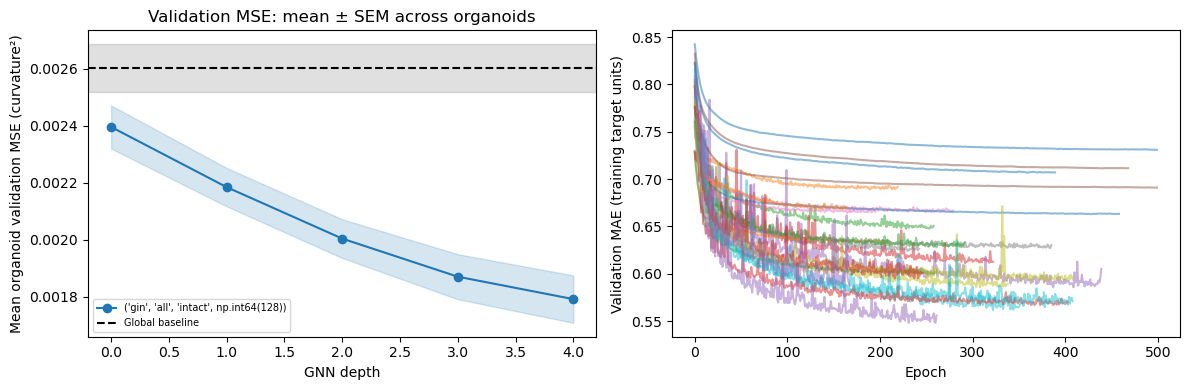

,key,name,subset,signal,depth,hidden_dim,fold,seed,bundle,input_bundle
0,gin_all_intact_d0_h128_f0_s42,gin,all,intact,0,128,0,42,models/gin_all_intact_d0_h128_f0_s42,inputs/fold_0_all_intact
1,gin_all_intact_d1_h128_f0_s42,gin,all,intact,1,128,0,42,models/gin_all_intact_d1_h128_f0_s42,inputs/fold_0_all_intact
2,gin_all_intact_d2_h128_f0_s42,gin,all,intact,2,128,0,42,models/gin_all_intact_d2_h128_f0_s42,inputs/fold_0_all_intact
3,gin_all_intact_d3_h128_f0_s42,gin,all,intact,3,128,0,42,models/gin_all_intact_d3_h128_f0_s42,inputs/fold_0_all_intact
4,gin_all_intact_d4_h128_f0_s42,gin,all,intact,4,128,0,42,models/gin_all_intact_d4_h128_f0_s42,inputs/fold_0_all_intact
5,gin_all_intact_d0_h128_f1_s42,gin,all,intact,0,128,1,42,models/gin_all_intact_d0_h128_f1_s42,inputs/fold_1_all_intact
6,gin_all_intact_d1_h128_f1_s42,gin,all,intact,1,128,1,42,models/gin_all_intact_d1_h128_f1_s42,inputs/fold_1_all_intact
7,gin_all_intact_d2_h128_f1_s42,gin,all,intact,2,128,1,42,models/gin_all_intact_d2_h128_f1_s42,inputs/fold_1_all_intact
8,gin_all_intact_d3_h128_f1_s42,gin,all,intact,3,128,1,42,models/gin_all_intact_d3_h128_f1_s42,inputs/fold_1_all_intact
9,gin_all_intact_d4_h128_f1_s42,gin,all,intact,4,128,1,42,models/gin_all_intact_d4_h128_f1_s42,inputs/fold_1_all_intact


Restored validation organoids: 135


In [7]:
from src.analysis.metrics.evaluation import organoid_mse_summary
baseline_df = pd.DataFrame(baseline_rows)
scores_df = compare_baseline_mse(scores, baseline_rows)
display(scores_df.groupby(['name','subset','signal','depth'])[['mse','baseline_mse','mse_minus_baseline']].mean())
display(organoid_mse_summary(scores_df, ['name','subset','signal','hidden_dim','depth']))
display(organoid_mse_summary(baseline_df, ['fold']))
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for label, frame in scores_df.groupby(['name','subset','signal','hidden_dim']):
    curve = organoid_mse_summary(frame, 'depth')
    line, = axes[0].plot(curve.depth, curve['mean'], 'o-', label=str(label))
    axes[0].fill_between(curve.depth, curve['mean'] - curve['sem'], curve['mean'] + curve['sem'],
                         color=line.get_color(), alpha=.18)
for key, history in histories.items():
    axes[1].plot(history['val_mae'], alpha=.5, label=key)
axes[0].set(xlabel='GNN depth', ylabel='Mean organoid validation MSE (curvature²)')
baseline_curve = organoid_mse_summary(baseline_df).iloc[0]
axes[0].axhline(baseline_curve['mean'], color='black', linestyle='--', label='Global baseline')
if pd.notna(baseline_curve['sem']):
    axes[0].axhspan(baseline_curve['mean'] - baseline_curve['sem'],
                   baseline_curve['mean'] + baseline_curve['sem'], color='black', alpha=.12)
axes[0].set_title('Validation MSE: mean ± SEM across organoids')
axes[0].legend(fontsize=7)
axes[1].set(xlabel='Epoch', ylabel='Validation MAE (training target units)')
plt.tight_layout(); plt.show()
# Reopen independently, with no training or preprocessing fit:
from src.artifacts.runs import AnalysisRun
saved = AnalysisRun(RUN_DIR)
display(saved.records)
restored = saved.select(saved.records.iloc[0].key)
print('Restored validation organoids:', len(restored['groups']['val']))

## Validation MSE by anatomical region and model depth

Reopen every saved checkpoint and evaluate its validation cells with the saved inputs, target transform, and baseline. Regions are derived directly from the source dataset's `d_crypts_graph` and `proj_vertex_ids` arrays and the original segmentation file named in each organoid's metadata. No tables from another experiment are loaded. Annotation settings are near the top of this notebook.

Use the **original nearest crypt**, checked against segmentation distances at each cell's projected vertex. Its circumference must have a supported local minimum or flat section near s=1 and enough assigned cells. Within these qualified territories, s<0.8 is crypt body, 0.8≤s≤1.2 is neck, and s>1.2 is the operational villus distance proxy (thresholds are configurable). Cells are never reassigned from an unqualified crypt to a farther qualified one. Missing annotations, no detected crypts, and unqualified territories remain separate in the support and score tables, rather than being labelled villus. Small undetected crypts remain a limitation of the source annotations.

Each panel shows physical-curvature MSE against depth for all saved folds, with separate curves for model variants and a dashed global baseline. First average squared errors within each organoid/region, then average repeated seeds or validation appearances within each organoid. Shading is ±1 SEM across organoids, conditional on the fitted models. A single trained depth produces a single point; SEM is absent with fewer than two organoids. Masking models are evaluated with all fates observed. Model inputs and fitting are unchanged.

Save per-organoid MSE, node-aligned region assignments and their source paths, support counts, summaries, settings, and the figure under the training run's `regional_evaluation/` folder. This section can also be rerun on an existing `RUN_DIR` without retraining, after restoring imports, `DEVICE`, and `REGION_SETTINGS`.


,,organoids,cells
region,annotation_status,,
crypt,available,227,24083
neck,available,227,22441
no_detected_crypt,no_detected_crypt,42,18952
unqualified_crypt,available,572,204467
villus,available,218,46218


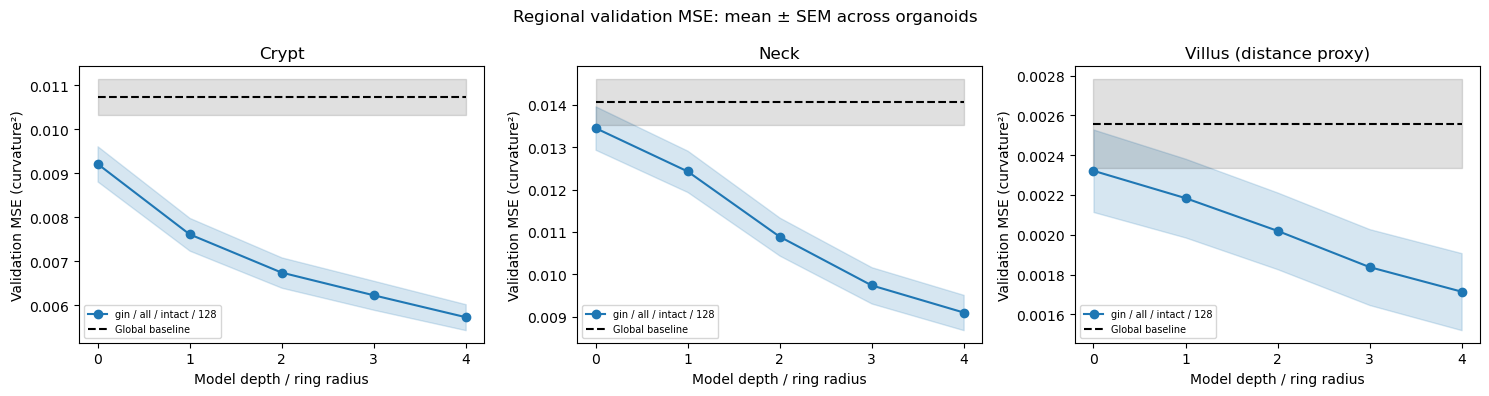

In [8]:
from src.analysis.spatial.regions import graph_regions
from src.analysis.metrics.evaluation import prediction_table, regional_mse
from src.plotting.depth_scan import plot_regional_mse

regional_run = AnalysisRun(RUN_DIR)
region_dataset_name = (regional_run.settings['dataset'] if regional_run.modern
                       else regional_run.legacy.settings['DATASET_NAME'])
region_data_dir = ROOT / 'training_data' / region_dataset_name
region_output = RUN_DIR / 'regional_evaluation'
region_output.mkdir(exist_ok=True)
(region_output / 'settings.json').write_text(json.dumps(
    dict(dataset=str(region_data_dir), **REGION_SETTINGS), indent=2))
region_annotations = {}
region_score_parts = []
for regional_record in regional_run.records.to_dict('records'):
    selected = regional_run.select(regional_record['key'], device=DEVICE)
    for graph in selected['groups']['val']:
        if graph.organoid_str not in region_annotations:
            raw_graph = selected['raw_graphs'][graph.organoid_str]
            region_annotations[graph.organoid_str] = graph_regions(raw_graph, region_data_dir, **REGION_SETTINGS)
    annotations = pd.concat([region_annotations[g.organoid_str] for g in selected['groups']['val']], ignore_index=True)
    predictions = prediction_table(selected, device=DEVICE)
    if 'baseline_squared_error' not in predictions:
        raise ValueError('Saved per-node baseline predictions are required for regional comparison.')
    regional_scores = regional_mse(predictions, annotations)
    for column in ('key', 'name', 'subset', 'signal', 'hidden_dim', 'depth', 'fold', 'seed', 'rate'):
        if column in regional_record:
            regional_scores[column] = regional_record[column]
    region_score_parts.append(regional_scores)
    del selected, predictions
regional_scores = pd.concat(region_score_parts, ignore_index=True)
regional_scores.to_csv(region_output / 'validation_mse.csv', index=False)
annotations = pd.concat(region_annotations.values(), ignore_index=True)
annotations.to_csv(region_output / 'node_regions.csv.gz', index=False)
region_support = annotations.groupby(['region', 'annotation_status']).agg(
    organoids=('organoid_str', 'nunique'), cells=('node', 'size'))
region_support.to_csv(region_output / 'annotation_support.csv')
display(region_support)
variant_columns = [c for c in ('name', 'subset', 'signal', 'hidden_dim', 'rate', 'depth', 'region') if c in regional_scores]
regional_summary = organoid_mse_summary(regional_scores, variant_columns)
regional_summary.to_csv(region_output / 'mse_summary.csv', index=False)
regional_baseline_summary = organoid_mse_summary(regional_scores, ['depth', 'region'], value='baseline_mse')
regional_baseline_summary.to_csv(region_output / 'baseline_mse_summary.csv', index=False)
fig = plot_regional_mse(regional_scores)
fig.savefig(region_output / 'mse_by_depth.png', dpi=160, bbox_inches='tight')
plt.show()
